In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [58]:
df = pd.read_csv('../data/prepared/tmp.csv')

In [59]:
def set_group(x):
    if x < 25:
        return 'young age'
    if ((x >= 25) & (x < 44)):
        return 'young age \n(adults)'
    if ((x >= 44) & (x < 60)):
        return 'middle age'
    if ((x >= 60) & (x < 75)):
        return 'elderly age'
    if ((x >= 75) & (x < 90)):
        return 'senile age'
    if x >= 90:
        return 'long-livers'    

In [60]:
df['Education: 0 school; 1 technical college; 2 university'].value_counts()

2.0    31
0.0    25
1.0    23
Name: Education: 0 school; 1 technical college; 2 university, dtype: int64

In [61]:
# df[(df['Age'] >= 19) & (df['Age'] < 25)]

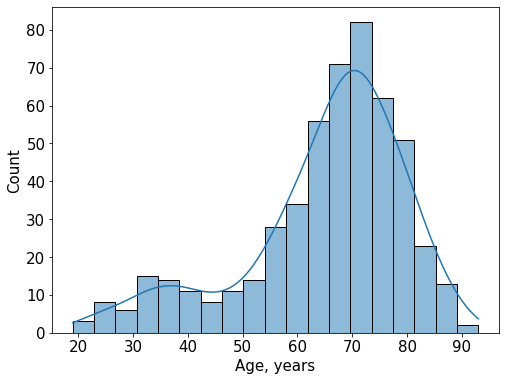

In [62]:
# Histogram
fig, ax = plt.subplots(figsize=(8, 6))
plt.rcParams.update({'font.size': 15})
figure_name = '../figure/age.svg'
sns.histplot(x=df['Age'], kde = True)
plt.xlabel('Age, years')
plt.savefig(figure_name, format='svg', dpi=200, bbox_inches='tight', pad_inches=0)

# По группам

In [63]:
df['groups'] = df['Age'].apply(set_group)

In [64]:
# df = df[(df['Age'] >= 25) & (df['Age'] < 90)]

In [66]:
# df['Gender: F, M']

In [67]:
# df.dropna(subset=['groups', 'Age', 'Gender: F, M'])

In [68]:
df = df.sort_values(by='Age')

In [69]:
df['groups'].unique()

array(['young age', 'young age \n(adults)', 'middle age', 'elderly age',
       'senile age', 'long-livers', None], dtype=object)

In [70]:
df['Gender: F, M'] = df['Gender: F, M'].replace({0: 'male', 1: 'female'})

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


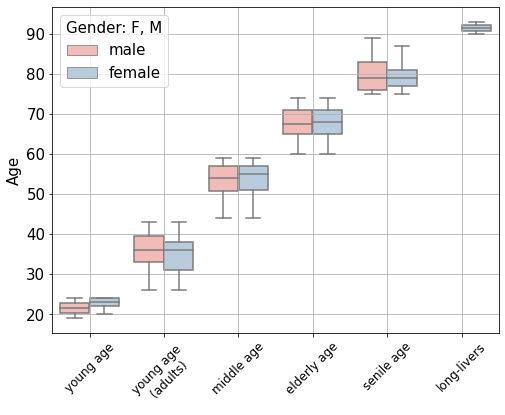

In [71]:
# set a grey background (use sns.set_theme() if seaborn version 0.11.0 or above) 
# sns.set(style="darkgrid")
fig, ax = plt.subplots(figsize=(8, 6))
    
# Grouped violinplot
sns.boxplot(x="groups", y="Age", hue='Gender: F, M', data=df, palette="Pastel1", showfliers=False)
# plt.legend()
ax.set_xticklabels(df['groups'].unique()[:-1], rotation=45, ha='center', fontsize=12)
plt.grid()
# plt.show()
plt.xlabel('')
plt.savefig('../figure/age_by_group.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)


In [72]:
# df = df.dropna(subset=['Education: 0 school; 1 technical college; 2 university'])

In [73]:
k = df[df['Hearing Aid Status: 0 no; 1 AD; 2 AS; 3 AD+AS; 4 does not use'] == 1]

In [134]:
len(df.values[0])

81

In [74]:
k = df[df['Monosyllabic speech in quiet, right, %'] < 80]

In [75]:
k = k[((k["Education: 0 school; 1 technical college; 2 university"] == 2) & (k['Dichotic test, %'] > 40) |
      (k["Education: 0 school; 1 technical college; 2 university"] == 0) | 
     (k["Education: 0 school; 1 technical college; 2 university"] == 1))]

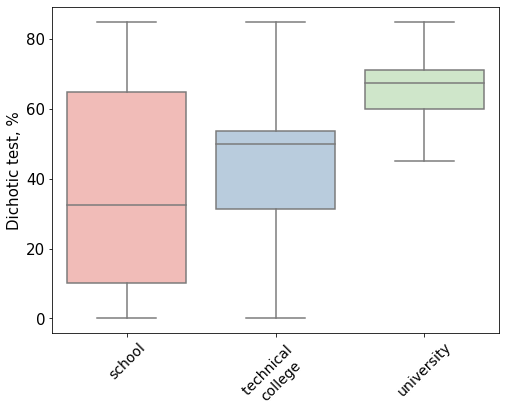

In [76]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(x="Education: 0 school; 1 technical college; 2 university", 
               y='Dichotic test, %', data=k, palette="Pastel1")

ax.set_xticklabels(['school', 'technical \ncollege', 'university'], rotation=45, ha='center', fontsize=14)
# Multisyllabic speech without HA in babble noise FF, %
# 'Monosyllabic speech in quiet, right, %'

plt.ylabel('Dichotic test, %')
plt.xlabel('')
plt.savefig('../figure/cognitive_by_group2.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)

In [77]:
# 'mean PTA AC right 0.5,1,2,4 ', 'mean PTA AC left 0.5,1,2,4'

In [78]:
x = 'Dichotic test, %'
# y = 'mean PTA AC right 0.5,1,2,4 '
y_col = 'mean PTA AC left 0.5,1,2,4'

In [79]:
k = df.dropna(subset=[x, y_col])

In [80]:
from sklearn.linear_model import LinearRegression

X, y = k[x].values, k[y_col]
reg = LinearRegression().fit(X.reshape(-1, 1), y)
reg.score(X.reshape(-1, 1), y)

0.034080270064778095

In [81]:
df['mean PTA AC left 0.5,1,2,4']

19       NaN
14       NaN
21       NaN
10       NaN
164    55.00
       ...  
225    47.50
260    72.50
444      NaN
273    68.75
512      NaN
Name: mean PTA AC left 0.5,1,2,4, Length: 513, dtype: float64

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


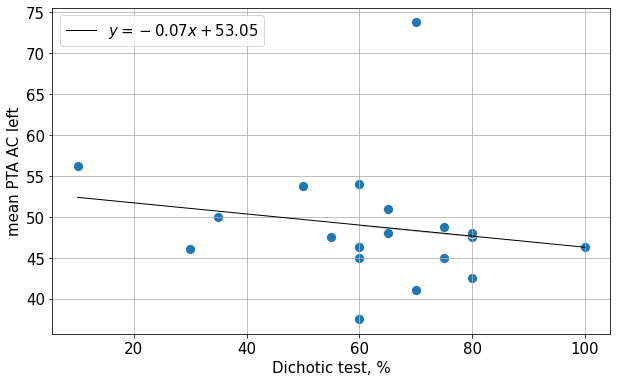

In [82]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[x], y=df[y_col], s=100)
# plt.xlabel(k1)

plt.ylabel('mean PTA AC left')
plt.legend()
plt.grid()

sns.lineplot(x=X, y=reg.predict(X.reshape(-1, 1)),
         color='k',
         label=fr'$y = {round(reg.coef_[0], 2)}x + {round(reg.intercept_, 2)}$',linewidth=1.0)

plt.legend()

plt.savefig('../figure/dich_mean_left.eps', format='eps', dpi=1200, bbox_inches = 'tight',
    pad_inches = 0)

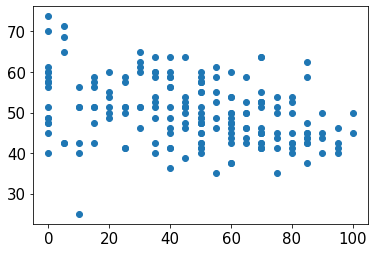

In [83]:
plt.scatter(df[x], df['mean PTA AC right 0.5,1,2,4 '])

дается расширенная картина эпидемологии -- как исследуемые факторы (прежде всего интегральные, как степень тугоухости) зависят от анамнеза (distribution of hearing loss levels over age groups, occupations, other factors associated with medical history)

In [84]:
x = 'Right HL degree: 0=no HL; 1-4; 5=deafness'
# y = 'Monosyllabic speech in quiet, right, %'
# y = 'RuMatrix in quiet right, dB SPL'
# y = 'Multisyllabic speech without HA in quiet FF, %'
y = 'Dichotic test, %'

In [85]:
# k = df[df[x] <= 3]

In [86]:
# fig, ax = plt.subplots(figsize=(8, 6))

# sns.boxplot(x=x, y=y, data=k, palette="Pastel1", showfliers=False)

# # plt.legend()
# ax.set_xticklabels([2, 3], rotation=0, ha='center', fontsize=16)
# plt.grid()
# # plt.show()
# # plt.xlabel('')
# plt.savefig('../figure/HL_degree_dich_right.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)

In [87]:
x = 'Left HL degree: 0=no HL; 1-4; 5=deafness'
y = 'Monosyllabic speech in quiet, left, %'
# y = 'RuMatrix in quiet left, dB SPL'
# y = 'Multisyllabic speech without HA in quiet FF, %'
y = 'Multisyllabic speech without HA in babble noise FF, %'
y = 'Dichotic test, %'

In [88]:
k = df

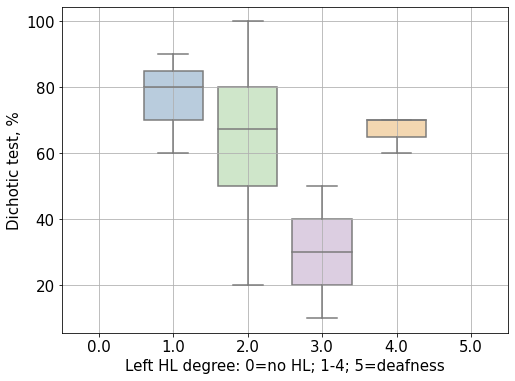

In [89]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(x=x, y=y, data=k, palette="Pastel1", showfliers=False)

# plt.legend()
# ax.set_xticklabels([2, 3], rotation=0, ha='center', fontsize=16)
plt.grid()
# plt.show()
# plt.xlabel('')
plt.savefig('../figure/HL_degree_multi_left.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)

In [90]:
df.columns

Index(['#', 'PTA right 125Hz AC', 'PTA right 250Hz AC', 'PTA right 500Hz AC',
       'PTA right 1000Hz AC', 'PTA right 2000Hz AC', 'PTA right 4000Hz AC',
       'PTA right 8000Hz AC', 'PTA left 125Hz AC', 'PTA left 250Hz AC',
       'PTA left 500Hz AC', 'PTA left 1000Hz AC', 'PTA left 2000Hz AC',
       'PTA left 4000Hz AC', 'PTA left 8000Hz AC', 'PTA right 250Hz BC',
       'PTA right 500Hz BC', 'PTA right 1000Hz BC', 'PTA right 2000Hz BC',
       'PTA right 4000Hz BC', 'PTA left 250Hz BC', 'PTA left 500Hz BC',
       'PTA left 1000Hz BC', 'PTA left 2000Hz BC', 'PTA left 4000Hz BC',
       'mean PTA AC right 0.5,1,2,4 ', 'mean PTA AC left 0.5,1,2,4',
       'Right HL degree: 0=no HL; 1-4; 5=deafness',
       'Left HL degree: 0=no HL; 1-4; 5=deafness',
       'Right HL type: 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL',
       'Left HL type 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL', 'DS: notes',
       'UCL right 0.5kHz', 'UCL right 1kHz', 'UCL right 2kHz',
       'UCL right 4kHz', 'U

In [91]:
# k = df[(df['Age'] < 90)]
# k = df[(df['Age'] >= 25) & (df['Age'] < 90)]
k = df

In [92]:
# k = k[k['groups'] != 'middle age']

In [98]:
k = k.sort_values('Age')

k = k[k['groups'] != 'long-livers']

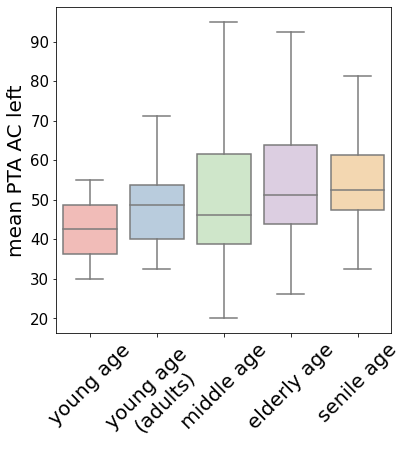

In [99]:
# set a grey background (use sns.set_theme() if seaborn version 0.11.0 or above) 
# sns.set(style="darkgrid")
fig, ax = plt.subplots(figsize=(6, 6))
    
# Grouped violinplot
sns.boxplot(x="groups", y='mean PTA AC left 0.5,1,2,4', data=k, palette="Pastel1", showfliers=False)
# plt.legend()
ax.set_xticklabels(k['groups'].unique()[:-1], rotation=45, ha='center', fontsize=20)
ax.set_ylabel('mean PTA AC left', fontsize=20)
# plt.show()
plt.xlabel('')
plt.savefig('../figure/mean_PTA_left_by_group.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)

In [100]:
k = df

k = k.sort_values('Age')

# k = k[k['groups'] != 'long-livers']

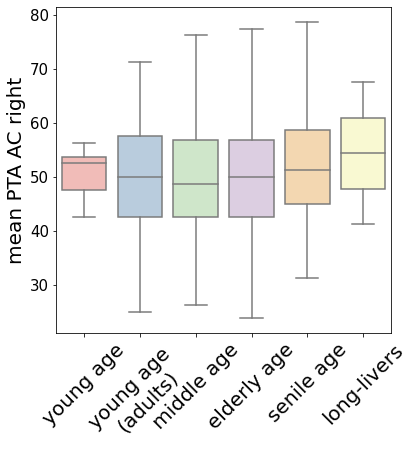

In [107]:
# set a grey background (use sns.set_theme() if seaborn version 0.11.0 or above) 
# sns.set(style="darkgrid")
fig, ax = plt.subplots(figsize=(6, 6))
    
# Grouped violinplot
sns.boxplot(x="groups", y='mean PTA AC right 0.5,1,2,4 ', data=k, palette="Pastel1", showfliers=False)
# plt.legend()
ax.set_xticklabels(k['groups'].unique()[:-1], rotation=45, ha='center', fontsize=20)
ax.set_ylabel('mean PTA AC right', fontsize=20)
# plt.show()
plt.xlabel('')
plt.savefig('../figure/mean_PTA_right_by_group.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)

In [106]:
df.columns

Index(['#', 'PTA right 125Hz AC', 'PTA right 250Hz AC', 'PTA right 500Hz AC',
       'PTA right 1000Hz AC', 'PTA right 2000Hz AC', 'PTA right 4000Hz AC',
       'PTA right 8000Hz AC', 'PTA left 125Hz AC', 'PTA left 250Hz AC',
       'PTA left 500Hz AC', 'PTA left 1000Hz AC', 'PTA left 2000Hz AC',
       'PTA left 4000Hz AC', 'PTA left 8000Hz AC', 'PTA right 250Hz BC',
       'PTA right 500Hz BC', 'PTA right 1000Hz BC', 'PTA right 2000Hz BC',
       'PTA right 4000Hz BC', 'PTA left 250Hz BC', 'PTA left 500Hz BC',
       'PTA left 1000Hz BC', 'PTA left 2000Hz BC', 'PTA left 4000Hz BC',
       'mean PTA AC right 0.5,1,2,4 ', 'mean PTA AC left 0.5,1,2,4',
       'Right HL degree: 0=no HL; 1-4; 5=deafness',
       'Left HL degree: 0=no HL; 1-4; 5=deafness',
       'Right HL type: 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL',
       'Left HL type 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL', 'DS: notes',
       'UCL right 0.5kHz', 'UCL right 1kHz', 'UCL right 2kHz',
       'UCL right 4kHz', 'U

In [108]:
k = df

k = k.sort_values('Age')

# k = k[k['groups'] != 'long-livers']

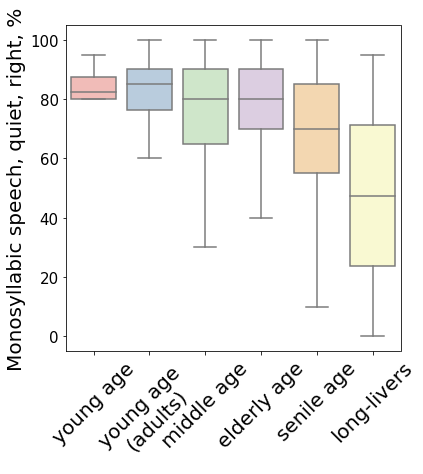

In [110]:
# set a grey background (use sns.set_theme() if seaborn version 0.11.0 or above) 
# sns.set(style="darkgrid")
fig, ax = plt.subplots(figsize=(6, 6))
    
# Grouped violinplot
sns.boxplot(x="groups", y='Monosyllabic speech in quiet, right, %', data=k, palette="Pastel1", showfliers=False)
# plt.legend()
ax.set_xticklabels(k['groups'].unique()[:-1], rotation=45, ha='center', fontsize=20)
ax.set_ylabel('Monosyllabic speech, quiet, right, %', fontsize=20)
# plt.show()
plt.xlabel('')
plt.savefig('../figure/mono_by_group.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)

In [111]:
df.columns

Index(['#', 'PTA right 125Hz AC', 'PTA right 250Hz AC', 'PTA right 500Hz AC',
       'PTA right 1000Hz AC', 'PTA right 2000Hz AC', 'PTA right 4000Hz AC',
       'PTA right 8000Hz AC', 'PTA left 125Hz AC', 'PTA left 250Hz AC',
       'PTA left 500Hz AC', 'PTA left 1000Hz AC', 'PTA left 2000Hz AC',
       'PTA left 4000Hz AC', 'PTA left 8000Hz AC', 'PTA right 250Hz BC',
       'PTA right 500Hz BC', 'PTA right 1000Hz BC', 'PTA right 2000Hz BC',
       'PTA right 4000Hz BC', 'PTA left 250Hz BC', 'PTA left 500Hz BC',
       'PTA left 1000Hz BC', 'PTA left 2000Hz BC', 'PTA left 4000Hz BC',
       'mean PTA AC right 0.5,1,2,4 ', 'mean PTA AC left 0.5,1,2,4',
       'Right HL degree: 0=no HL; 1-4; 5=deafness',
       'Left HL degree: 0=no HL; 1-4; 5=deafness',
       'Right HL type: 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL',
       'Left HL type 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL', 'DS: notes',
       'UCL right 0.5kHz', 'UCL right 1kHz', 'UCL right 2kHz',
       'UCL right 4kHz', 'U

In [114]:
k = df

k = k.sort_values('Age')
k = k[k['groups'] != 'long-livers']

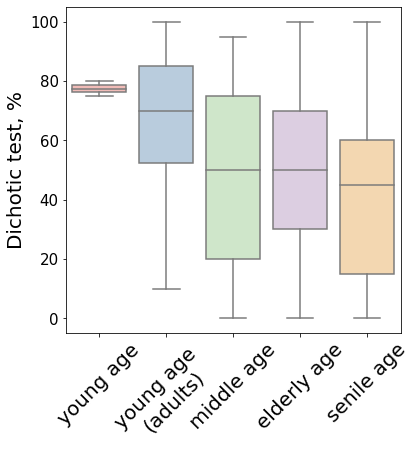

In [115]:
# set a grey background (use sns.set_theme() if seaborn version 0.11.0 or above) 
# sns.set(style="darkgrid")
fig, ax = plt.subplots(figsize=(6, 6))
    
# Grouped violinplot
sns.boxplot(x="groups", y='Dichotic test, %', data=k, palette="Pastel1", showfliers=False)
# plt.legend()
ax.set_xticklabels(k['groups'].unique()[:-1], rotation=45, ha='center', fontsize=20)
ax.set_ylabel('Dichotic test, %', fontsize=20)
# plt.show()
plt.xlabel('')
plt.savefig('../figure/dichotic_by_group.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)

In [116]:
df.columns

Index(['#', 'PTA right 125Hz AC', 'PTA right 250Hz AC', 'PTA right 500Hz AC',
       'PTA right 1000Hz AC', 'PTA right 2000Hz AC', 'PTA right 4000Hz AC',
       'PTA right 8000Hz AC', 'PTA left 125Hz AC', 'PTA left 250Hz AC',
       'PTA left 500Hz AC', 'PTA left 1000Hz AC', 'PTA left 2000Hz AC',
       'PTA left 4000Hz AC', 'PTA left 8000Hz AC', 'PTA right 250Hz BC',
       'PTA right 500Hz BC', 'PTA right 1000Hz BC', 'PTA right 2000Hz BC',
       'PTA right 4000Hz BC', 'PTA left 250Hz BC', 'PTA left 500Hz BC',
       'PTA left 1000Hz BC', 'PTA left 2000Hz BC', 'PTA left 4000Hz BC',
       'mean PTA AC right 0.5,1,2,4 ', 'mean PTA AC left 0.5,1,2,4',
       'Right HL degree: 0=no HL; 1-4; 5=deafness',
       'Left HL degree: 0=no HL; 1-4; 5=deafness',
       'Right HL type: 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL',
       'Left HL type 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL', 'DS: notes',
       'UCL right 0.5kHz', 'UCL right 1kHz', 'UCL right 2kHz',
       'UCL right 4kHz', 'U

In [122]:
k = df

k = k.sort_values('Age')
k = k[k['groups'] != 'long-livers']
k = k[k['groups'] != 'young age']

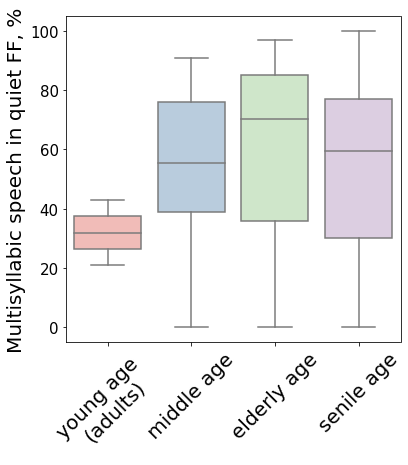

In [123]:
# set a grey background (use sns.set_theme() if seaborn version 0.11.0 or above) 
# sns.set(style="darkgrid")
fig, ax = plt.subplots(figsize=(6, 6))
    
# Grouped violinplot
sns.boxplot(x="groups", y='Multisyllabic speech without HA in quiet FF, %', data=k, palette="Pastel1", showfliers=False)
# plt.legend()
ax.set_xticklabels(k['groups'].unique()[:-1], rotation=45, ha='center', fontsize=20)
ax.set_ylabel('Multisyllabic speech in quiet FF, %', fontsize=20)
# plt.show()
plt.xlabel('')
plt.savefig('../figure/multi_by_group.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)

In [129]:
k = df

k = k.sort_values('Age')
k = k[k['groups'] != 'long-livers']
k = k[k['groups'] != 'young age']
k = k[k['groups'] != 'middle age']

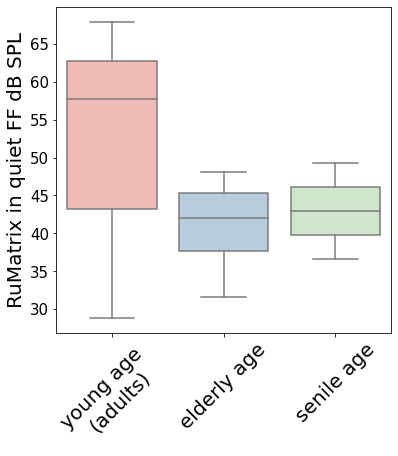

In [130]:
# set a grey background (use sns.set_theme() if seaborn version 0.11.0 or above) 
# sns.set(style="darkgrid")
fig, ax = plt.subplots(figsize=(6, 6))
    
# Grouped violinplot
sns.boxplot(x="groups", y='RuMatrix in quiet FF dB SPL', data=k, palette="Pastel1", showfliers=False)
# plt.legend()
ax.set_xticklabels(k['groups'].unique()[:-1], rotation=45, ha='center', fontsize=20)
ax.set_ylabel('RuMatrix in quiet FF dB SPL', fontsize=20)
# plt.show()
plt.xlabel('')
plt.savefig('../figure/RuMatrix_by_group.eps', format='eps', dpi=200, bbox_inches='tight', pad_inches=0)

In [124]:
df.columns

Index(['#', 'PTA right 125Hz AC', 'PTA right 250Hz AC', 'PTA right 500Hz AC',
       'PTA right 1000Hz AC', 'PTA right 2000Hz AC', 'PTA right 4000Hz AC',
       'PTA right 8000Hz AC', 'PTA left 125Hz AC', 'PTA left 250Hz AC',
       'PTA left 500Hz AC', 'PTA left 1000Hz AC', 'PTA left 2000Hz AC',
       'PTA left 4000Hz AC', 'PTA left 8000Hz AC', 'PTA right 250Hz BC',
       'PTA right 500Hz BC', 'PTA right 1000Hz BC', 'PTA right 2000Hz BC',
       'PTA right 4000Hz BC', 'PTA left 250Hz BC', 'PTA left 500Hz BC',
       'PTA left 1000Hz BC', 'PTA left 2000Hz BC', 'PTA left 4000Hz BC',
       'mean PTA AC right 0.5,1,2,4 ', 'mean PTA AC left 0.5,1,2,4',
       'Right HL degree: 0=no HL; 1-4; 5=deafness',
       'Left HL degree: 0=no HL; 1-4; 5=deafness',
       'Right HL type: 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL',
       'Left HL type 0=no HL; 1=SNHL; 2=conductive; 3= mixed HL', 'DS: notes',
       'UCL right 0.5kHz', 'UCL right 1kHz', 'UCL right 2kHz',
       'UCL right 4kHz', 'U